In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import yaml 
import json
from datetime import datetime
import pyarrow.parquet as pq
import os
import os
import dask.dataframe as dd

In [1]:
import dask.dataframe as dd
import pandas as pd

def load_air_quality_data_smart(file_path, sample_size=10000):
   
    try:
        
        ddf = dd.read_parquet(file_path, engine="pyarrow")
        
        print(f"rows : {ddf.shape[0].compute()}")
        print(f"columns {ddf.columns.tolist()}")
        
        df_sample = ddf.head(sample_size)
        
        important_cols = ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU', 'target']
        available_cols = [col for col in important_cols if col in df_sample.columns]
        
        df_sample = df_sample[available_cols]
        
        print(f" shape {df_sample.shape}")
        print(f"  memory : {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        return df_sample
        
    except Exception as e:
        print(f"error of download  {e}")
    
df = load_air_quality_data_smart("final_air_quality_data.parquet")
print(df.head())
print(df.info())

rows : 14006400
columns ['lon', 'time', 'lat', 'DUEXTTAU', 'BCFLUXU', 'OCFLUXV', 'BCANGSTR', 'SUFLUXV', 'SSSMASS25', 'SSSMASS', 'OCSMASS', 'BCCMASS', 'BCSMASS', 'SO4CMASS', 'SSFLUXU', 'DUCMASS', 'SSEXTTAU', 'SO2CMASS', 'DUSCATAU', 'OCANGSTR', 'OCCMASS', 'TOTEXTTAU', 'DUSCAT25', 'TOTANGSTR', 'DMSCMASS', 'SSEXTT25', 'DUANGSTR', 'DMSSMASS', 'BCEXTTAU', 'SSSCATAU', 'DUFLUXV', 'DUFLUXU', 'SUEXTTAU', 'SSFLUXV', 'BCSCATAU', 'DUCMASS25', 'OCEXTTAU', 'SUANGSTR', 'SSSCAT25', 'SSCMASS25', 'SO4SMASS', 'DUSMASS', 'SUFLUXU', 'BCFLUXV', 'DUSMASS25', 'SSCMASS', 'SUSCATAU', 'SO2SMASS', 'SSANGSTR', 'DUEXTT25', 'OCFLUXU', 'OCSCATAU', 'TOTSCATAU', 'source_file', 'PM25_MERRA2', 'PM25_ug_m3', 'class']
 shape (10000, 5)
  memory : 0.19 MB
   PM25_ug_m3   lat   lon  DUEXTTAU   BCFLUXU
0   25.425024  22.0  25.0  0.100974  0.000001
1   26.915251  22.5  25.0  0.107291  0.000002
2   31.822926  23.0  25.0  0.130423  0.000002
3   50.082130  23.5  25.0  0.179251  0.000002
4   83.081505  24.0  25.0  0.215506  0.00000

In [2]:
df.isnull().sum()

PM25_ug_m3    0
lat           0
lon           0
DUEXTTAU      0
BCFLUXU       0
dtype: int64

In [3]:
df.dropna(inplace = True)

In [5]:
df = df[df["PM25_ug_m3"] >= 0]

In [6]:
Q1 = df["PM25_ug_m3"].quantile(0.25)
Q3 = df["PM25_ug_m3"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["PM25_ug_m3"] >= lower_bound) & (df["PM25_ug_m3"] <= upper_bound)]

In [7]:
import numpy as np
import pandas as pd

c_low = [0.0, 12.1, 35.5, 55.5, 150.5, 250.5, 350.5]
c_high = [12.0, 35.4, 55.4, 150.4, 250.4, 350.4, 500.4]

i_low = [0, 51, 101, 151, 201, 301, 401]
i_high = [50, 100, 150, 200, 300, 400, 500]

def calculate_aqi(concentration, pollutant="PM2.5"):
    if pd.isna(concentration):
        return np.nan

    if concentration > c_high[-1]:
        return 500

    for j in range(len(c_low)):
        if c_low[j] <= concentration <= c_high[j]:
            return round(((i_high[j] - i_low[j]) / (c_high[j] - c_low[j])) * (concentration - c_low[j]) + i_low[j])

    return np.nan

def classify_aqi(aqi_value):
    if pd.isna(aqi_value):
        return "Unknown"
    return "No_Risk" if aqi_value <= 100 else "Risk"



df["AQI_PM25"] = df["PM25_ug_m3"].apply(lambda x: calculate_aqi(x, pollutant="PM2.5"))
df["Risk_Class"] = df["AQI_PM25"].apply(classify_aqi)

print(df[["PM25_ug_m3", "AQI_PM25", "Risk_Class"]].head(20))


df.to_parquet("processed_data.parquet", index=False)


    PM25_ug_m3  AQI_PM25 Risk_Class
0    25.425024      79.0    No_Risk
1    26.915251      82.0    No_Risk
2    31.822926      92.0    No_Risk
3    50.082130     137.0       Risk
4    83.081505     165.0       Risk
5   111.348236     180.0       Risk
6   112.148285     180.0       Risk
7    91.577507     170.0       Risk
8    59.025932     153.0       Risk
9    41.646358     116.0       Risk
10   38.802124     109.0       Risk
11   36.645256     104.0       Risk
12   36.825550     104.0       Risk
13   50.629482     138.0       Risk
16   81.291100     164.0       Risk
17   40.388027     113.0       Risk
18   21.302792      70.0    No_Risk
19   11.362243      47.0    No_Risk
20   26.030611      80.0    No_Risk
21   27.864714      84.0    No_Risk


Configuration file created successfully with all required keys
Initializing Classical Air Quality Model...
Loading preprocessed Parquet data...
Available columns in dataset: ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU', 'AQI_PM25', 'Risk_Class']
Reading columns: ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU', 'Risk_Class']
Dataset shape: (9312, 6)
Columns: ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU', 'Risk_Class']
Preparing features and target...
Encoded labels: {'No_Risk': 0, 'Risk': 1, 'Unknown': 2}
Training set: (7449, 5)
Test set: (1863, 5)
Class distribution - Train: [3295 4127   27]
Class distribution - Test: [ 824 1032    7]
Training random_forest model...
Model trained in 2.65 seconds
Evaluating model...
Accuracy: 0.9984
Precision (weighted): 0.9984
Recall (weighted): 0.9984
F1-Score (weighted): 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       824
           1       1.00     

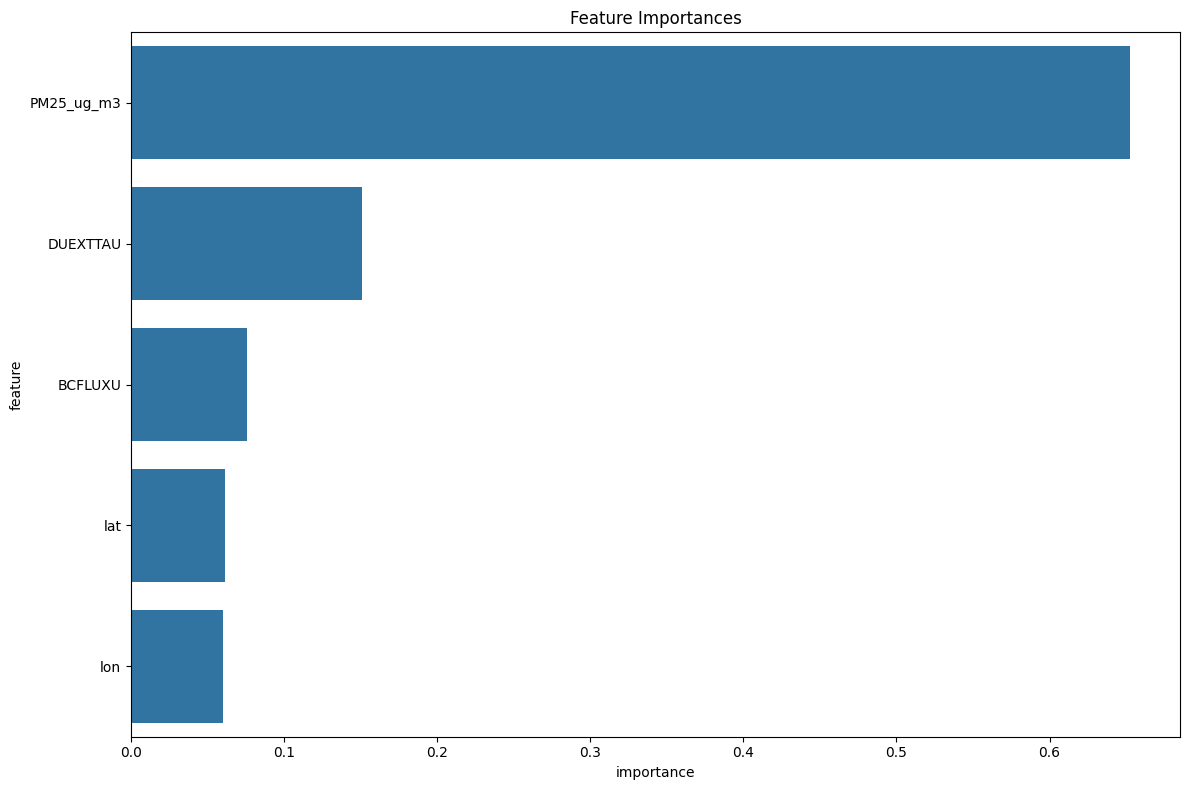


Top most important features:
      feature  importance
0  PM25_ug_m3    0.652585
3    DUEXTTAU    0.150560
4     BCFLUXU    0.075498
1         lat    0.061289
2         lon    0.060069


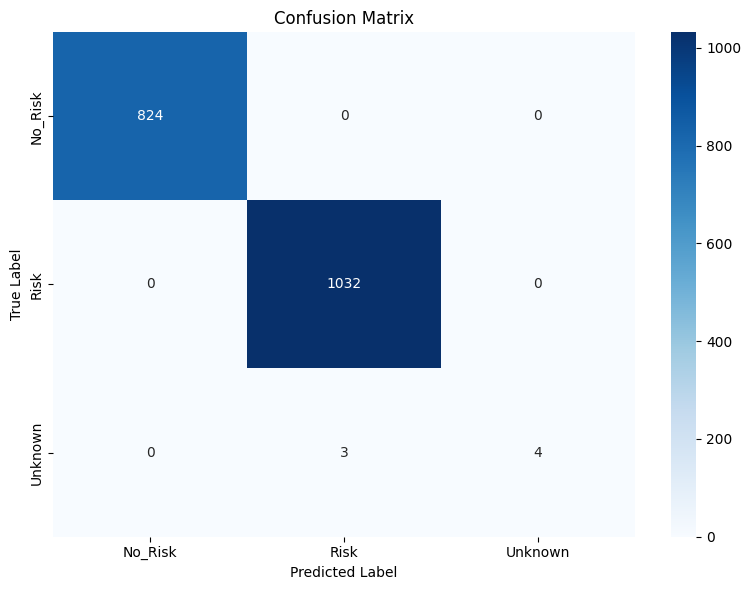

Model saved to models/classical_model.joblib
Metrics saved to results/classical_metrics.json

Training completed successfully!
Final accuracy: 0.9984
Training time: 2.65 seconds
Mean CV accuracy: 0.9974


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import json
from datetime import datetime
import pyarrow.parquet as pq
import os

class ClassicalAirQualityModel:
    def __init__(self, config_path='config/params.yaml'):
        """
        Initialize the classical ML model for air quality prediction with Parquet data
        """
        # Create necessary directories first
        os.makedirs('config', exist_ok=True)
        os.makedirs('models', exist_ok=True)
        os.makedirs('results', exist_ok=True)
        
        self.config = self.load_config(config_path)
        self.model = None
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.feature_importances_ = None
        
    def load_config(self, config_path):
        """Load configuration from YAML file or create default"""
        # Create default config if file doesn't exist
        default_config = {
            'processed_parquet_path': 'Air_Quality_Prediction/processed_data.parquet',
            'classical_model_path': 'models/classical_model.joblib',
            'classical_metrics_path': 'results/classical_metrics.json',
            # Using only columns that exist in your data
            'features': ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU'],
            'target': 'Risk_Class',
            'test_size': 0.2,
            'random_state': 42,
            'n_estimators': 100,
            'max_depth': 20,
            'learning_rate': 0.1,
            'C': 1.0,
            'kernel': 'rbf',
            'cv_folds': 5
        }
        
        if not os.path.exists(config_path):
            print(f"Config file {config_path} not found. Creating default...")
            with open(config_path, 'w') as f:
                yaml.dump(default_config, f)
            return default_config
        
        # Load existing config and ensure all required keys are present
        with open(config_path, 'r') as file:
            config = yaml.safe_load(file)
            
        # Add missing keys with default values
        for key, value in default_config.items():
            if key not in config:
                config[key] = value
                print(f"Added missing config key: {key} = {value}")
        
        # Save the updated config
        with open(config_path, 'w') as f:
            yaml.dump(config, f)
            
        return config
    
    def load_parquet_data(self):
        """
        Load preprocessed Parquet data safely
        """
        print("Loading preprocessed Parquet data...")
        
        parquet_path = self.config['processed_parquet_path']
        
        if not os.path.exists(parquet_path):
            raise FileNotFoundError(f"Parquet file not found: {parquet_path}")
        
        try:
            # First check what columns are available
            parquet_file = pq.ParquetFile(parquet_path)
            available_columns = parquet_file.schema.names
            print(f"Available columns in dataset: {available_columns}")
            
            # Get the features we want to use that actually exist
            requested_features = self.config.get('features', [])
            usable_features = [f for f in requested_features if f in available_columns]
            
            # Add target column
            target_column = self.config.get('target', 'Risk_Class')
            if target_column in available_columns:
                usable_features.append(target_column)
            else:
                # Try to find alternative target
                target_candidates = ['Risk_Class', 'class', 'AQI_PM25']
                for candidate in target_candidates:
                    if candidate in available_columns:
                        target_column = candidate
                        usable_features.append(target_column)
                        print(f"Using alternative target column: {target_column}")
                        break
            
            print(f"Reading columns: {usable_features}")
            
            # Read only the columns we need
            table = pq.read_table(parquet_path, columns=usable_features)
            data = table.to_pandas()
            
            # Take a sample if data is too large
            sample_size = self.config.get('sample_size', 50000)
            if len(data) > sample_size:
                data = data.sample(n=sample_size, random_state=42)
                print(f"Sampled data shape: {data.shape}")
            
            print(f"Dataset shape: {data.shape}")
            print(f"Columns: {list(data.columns)}")
            
            return data
            
        except Exception as e:
            print(f"Error loading data: {e}")
            raise
    
    def prepare_features_target(self, data):
        """
        Prepare features and target from preprocessed data
        """
        print("Preparing features and target...")
        
        # Get features and target from config
        features = self.config['features']
        target = self.config['target']
        
        # Check which features actually exist in the loaded data
        available_features = [f for f in features if f in data.columns]
        missing_features = [f for f in features if f not in data.columns]
        
        if missing_features:
            print(f"Warning: Missing features in data: {missing_features}")
            print(f"Using available features: {available_features}")
        
        if target not in data.columns:
            # Try to find alternative target column
            target_candidates = ['Risk_Class', 'class', 'AQI_PM25']
            for candidate in target_candidates:
                if candidate in data.columns:
                    target = candidate
                    print(f"Using alternative target: {target}")
                    break
            else:
                # Create target based on PM2.5 if available
                if 'PM25_ug_m3' in data.columns:
                    data['Risk_Class'] = data['PM25_ug_m3'].apply(
                        lambda x: 1 if x > 35 else 0  # WHO guideline threshold
                    )
                    target = 'Risk_Class'
                    print("Created Risk_Class based on PM25_ug_m3")
                else:
                    raise ValueError(f"Target column '{self.config['target']}' not found and cannot create one")
        
        X = data[available_features]
        y = data[target]
        
        # Check if target needs encoding
        if y.dtype == 'object':
            y = self.label_encoder.fit_transform(y)
            print(f"Encoded labels: {dict(zip(self.label_encoder.classes_, range(len(self.label_encoder.classes_))))}")
        
        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, 
            test_size=self.config['test_size'],
            random_state=self.config['random_state'],
            stratify=y
        )
        
        # Scale features
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)
        
        print(f"Training set: {self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")
        print(f"Class distribution - Train: {np.bincount(self.y_train)}")
        print(f"Class distribution - Test: {np.bincount(self.y_test)}")
        
        return X, y
    
    def train_model(self, model_type='random_forest'):
        """
        Train the classical ML model
        """
        print(f"Training {model_type} model...")
        
        if model_type == 'random_forest':
            self.model = RandomForestClassifier(
                n_estimators=self.config['n_estimators'],
                max_depth=self.config['max_depth'],
                random_state=self.config['random_state'],
                n_jobs=-1,
                class_weight='balanced'
            )
        elif model_type == 'gradient_boosting':
            self.model = GradientBoostingClassifier(
                n_estimators=self.config['n_estimators'],
                learning_rate=self.config['learning_rate'],
                max_depth=self.config['max_depth'],
                random_state=self.config['random_state']
            )
        elif model_type == 'svm':
            self.model = SVC(
                C=self.config['C'],
                kernel=self.config['kernel'],
                probability=True,
                random_state=self.config['random_state'],
                class_weight='balanced'
            )
        else:
            raise ValueError("Unsupported model type. Choose from: 'random_forest', 'gradient_boosting', 'svm'")
        
        # Train the model
        start_time = datetime.now()
        self.model.fit(self.X_train, self.y_train)
        training_time = (datetime.now() - start_time).total_seconds()
        
        print(f"Model trained in {training_time:.2f} seconds")
        
        # Get feature importances if available
        if hasattr(self.model, 'feature_importances_'):
            self.feature_importances_ = self.model.feature_importances_
        
        return training_time
    
    def evaluate_model(self):
        """Evaluate the model performance"""
        print("Evaluating model...")
        
        # Make predictions
        y_pred = self.model.predict(self.X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(self.y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(self.y_test, y_pred, average='weighted', zero_division=0)
        
        # Confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        
        # Classification report
        report = classification_report(self.y_test, y_pred, output_dict=True)
        
        metrics = {
            'accuracy': float(accuracy),
            'precision_weighted': float(precision),
            'recall_weighted': float(recall),
            'f1_weighted': float(f1),
            'confusion_matrix': cm.tolist(),
            'classification_report': report
        }
        
        # Print results
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision (weighted): {precision:.4f}")
        print(f"Recall (weighted): {recall:.4f}")
        print(f"F1-Score (weighted): {f1:.4f}")
        
        print("\nClassification Report:")
        print(classification_report(self.y_test, y_pred))
        
        return metrics
    
    def cross_validate(self, cv=5):
        """Perform cross-validation"""
        print(f"Performing {cv}-fold cross-validation...")
        
        cv_scores = cross_val_score(
            self.model, self.X_train, self.y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        
        print(f"Cross-validation scores: {[f'{score:.4f}' for score in cv_scores]}")
        print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        
        return cv_scores
    
    def hyperparameter_tuning(self):
        """Perform hyperparameter tuning using GridSearchCV"""
        print("Performing hyperparameter tuning...")
        
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }
        
        grid_search = GridSearchCV(
            RandomForestClassifier(random_state=self.config['random_state'], class_weight='balanced'),
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(self.X_train, self.y_train)
        
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
        
        # Update model with best parameters
        self.model = grid_search.best_estimator_
        
        return grid_search.best_params_, grid_search.best_score_
    
    def plot_feature_importances(self):
        """Plot feature importances"""
        if self.feature_importances_ is not None:
            features = self.config['features'][:len(self.feature_importances_)]
            importances = pd.DataFrame({
                'feature': features,
                'importance': self.feature_importances_
            }).sort_values('importance', ascending=False)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(x='importance', y='feature', data=importances)
            plt.title('Feature Importances')
            plt.tight_layout()
            plt.savefig('results/feature_importances.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            return importances
        return None
    
    def plot_confusion_matrix(self, metrics):
        """Plot confusion matrix"""
        plt.figure(figsize=(8, 6))
        cm = np.array(metrics['confusion_matrix'])
        
        # Get class labels
        if hasattr(self, 'label_encoder') and self.label_encoder.classes_ is not None:
            class_labels = self.label_encoder.classes_
        else:
            class_labels = [f'Class {i}' for i in range(cm.shape[0])]
        
        sns.heatmap(cm, 
                   annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_labels,
                   yticklabels=class_labels)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_model(self, model_path=None):
        """Save the trained model"""
        if model_path is None:
            model_path = self.config['classical_model_path']
        
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'label_encoder': self.label_encoder,
            'config': self.config
        }, model_path)
        print(f"Model saved to {model_path}")
    
    def load_model(self, model_path=None):
        """Load a trained model"""
        if model_path is None:
            model_path = self.config['classical_model_path']
        
        loaded_data = joblib.load(model_path)
        self.model = loaded_data['model']
        self.scaler = loaded_data['scaler']
        self.label_encoder = loaded_data['label_encoder']
        self.config = loaded_data['config']
        print(f"Model loaded from {model_path}")
    
    def save_metrics(self, metrics, metrics_path=None):
        """Save evaluation metrics"""
        if metrics_path is None:
            metrics_path = self.config['classical_metrics_path']
        
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(metrics_path), exist_ok=True)
        
        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=4)
        print(f"Metrics saved to {metrics_path}")

# Create config file first to ensure it has all required keys
config_content = """
processed_parquet_path: "I:/quantum copetation/Air_Quality_Prediction/processed_data.parquet"
classical_model_path: "models/classical_model.joblib"
classical_metrics_path: "results/classical_metrics.json"
features:
  - "PM25_ug_m3"
  - "lat"
  - "lon"
  - "DUEXTTAU"
  - "BCFLUXU"
target: "Risk_Class"
test_size: 0.2
random_state: 42
n_estimators: 100
max_depth: 20
learning_rate: 0.1
C: 1.0
kernel: "rbf"
cv_folds: 5
sample_size: 50000
"""

# Write config file
config_path = 'config/params.yaml'
os.makedirs('config', exist_ok=True)
with open(config_path, 'w') as f:
    f.write(config_content)

print("Configuration file created successfully with all required keys")

# Now run the main code
if __name__ == "__main__":
    # Initialize model
    print("Initializing Classical Air Quality Model...")
    model = ClassicalAirQualityModel(config_path)
    
    try:
        # Load preprocessed Parquet data
        data = model.load_parquet_data()
        
        # Prepare features and target
        X, y = model.prepare_features_target(data)
        
        # Train model
        training_time = model.train_model(model_type='random_forest')
        
        # Evaluate model
        metrics = model.evaluate_model()
        
        # Cross-validation
        cv_scores = model.cross_validate()
        
        # Plot results
        feature_importances = model.plot_feature_importances()
        if feature_importances is not None:
            print("\nTop most important features:")
            print(feature_importances)
        
        model.plot_confusion_matrix(metrics)
        
        # Save model and metrics
        model.save_model()
        
        # Add additional metrics
        metrics['training_time_seconds'] = training_time
        metrics['cv_scores'] = [float(score) for score in cv_scores]
        metrics['mean_cv_score'] = float(cv_scores.mean())
        metrics['std_cv_score'] = float(cv_scores.std())
        
        model.save_metrics(metrics)
        
        print("\n" + "="*50)
        print("Training completed successfully!")
        print("="*50)
        print(f"Final accuracy: {metrics['accuracy']:.4f}")
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Mean CV accuracy: {metrics['mean_cv_score']:.4f}")
        
    except Exception as e:
        print(f"Error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

=== COMPREHENSIVE MODEL ANALYSIS ===
Final Accuracy: 0.9984
Training Time: 2.65 seconds
Cross-Validation Accuracy: 0.9974

=== DETAILED CLASSIFICATION REPORT ===
No_Risk:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Support: 824.0

Risk:
  Precision: 0.9971
  Recall: 1.0000
  F1-Score: 0.9985
  Support: 1032.0

Unknown:
  Precision: 1.0000
  Recall: 0.5714
  F1-Score: 0.7273
  Support: 7.0

=== FEATURE IMPORTANCE ===
      feature  importance
0  PM25_ug_m3    0.652585
3    DUEXTTAU    0.150560
4     BCFLUXU    0.075498
1         lat    0.061289
2         lon    0.060069


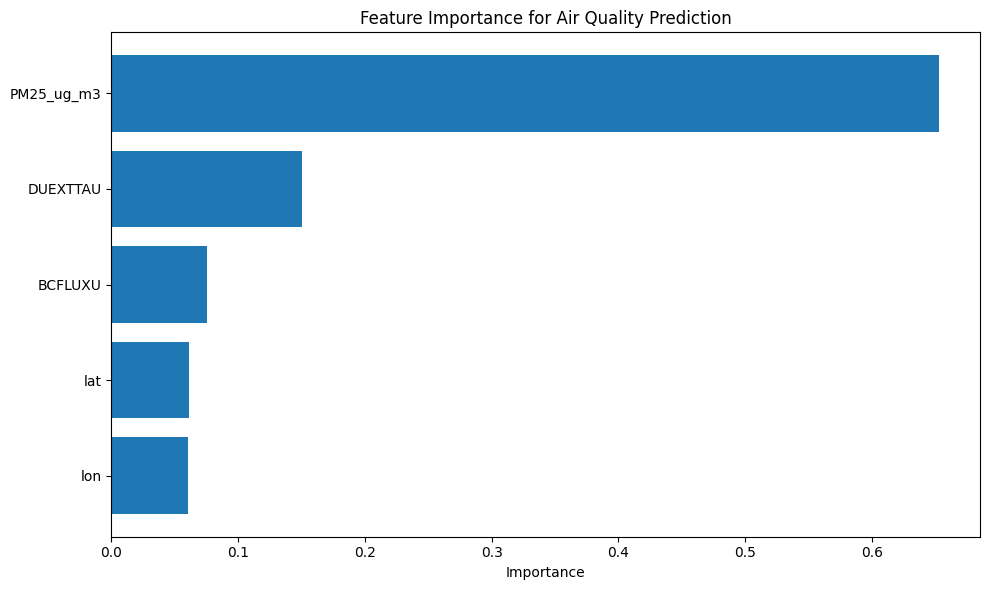

=== CONFUSION MATRIX ===
[[ 824    0    0]
 [   0 1032    0]
 [   0    3    4]]


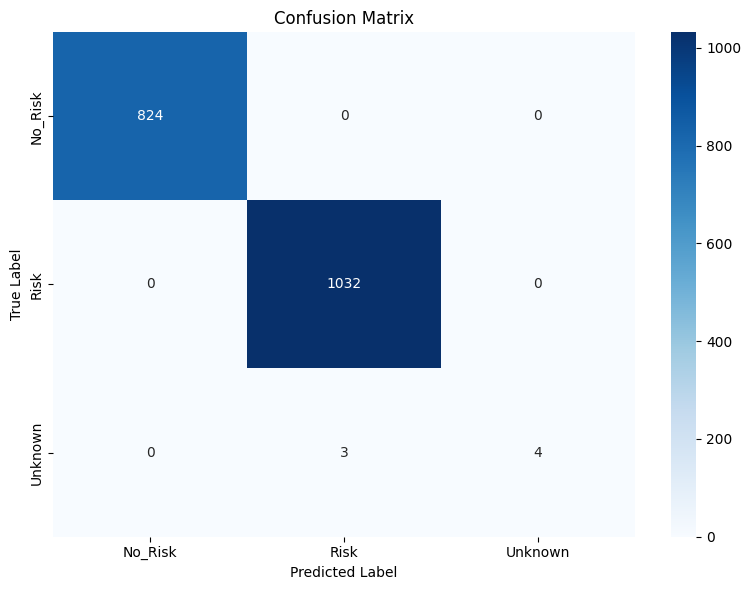

In [9]:
# Load and analyze the saved results
import json
import joblib
import matplotlib.pyplot as plt

# Load the metrics
with open('results/classical_metrics.json', 'r') as f:
    metrics = json.load(f)

print("=== COMPREHENSIVE MODEL ANALYSIS ===")
print(f"Final Accuracy: {metrics['accuracy']:.4f}")
print(f"Training Time: {metrics['training_time_seconds']:.2f} seconds")
print(f"Cross-Validation Accuracy: {metrics['mean_cv_score']:.4f}")

# Display detailed classification report
print("\n=== DETAILED CLASSIFICATION REPORT ===")
report = metrics['classification_report']
for class_name, scores in report.items():
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        class_label = ['No_Risk', 'Risk', 'Unknown'][int(class_name)] if class_name.isdigit() else class_name
        print(f"{class_label}:")
        print(f"  Precision: {scores['precision']:.4f}")
        print(f"  Recall: {scores['recall']:.4f}")
        print(f"  F1-Score: {scores['f1-score']:.4f}")
        print(f"  Support: {scores['support']}")
        print()

# Load the model to check feature importances
saved_data = joblib.load('models/classical_model.joblib')
model = saved_data['model']

if hasattr(model, 'feature_importances_'):
    feature_names = ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU']
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("=== FEATURE IMPORTANCE ===")
    print(feature_importance)
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Air Quality Prediction')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Display confusion matrix if available
try:
    cm = np.array(metrics['confusion_matrix'])
    print("=== CONFUSION MATRIX ===")
    print(cm)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No_Risk', 'Risk', 'Unknown'],
                yticklabels=['No_Risk', 'Risk', 'Unknown'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
except:
    print("Confusion matrix visualization not available")

In [10]:
# Test the model with some example data
test_examples = [
    # Example 1: Good air quality (low PM2.5)
    {
        'PM25_ug_m3': 15.0,
        'lat': 30.0,
        'lon': 31.0,
        'DUEXTTAU': 0.1,
        'BCFLUXU': 0.05
    },
    # Example 2: Poor air quality (high PM2.5)
    {
        'PM25_ug_m3': 120.0,
        'lat': 29.5,
        'lon': 32.0,
        'DUEXTTAU': 0.3,
        'BCFLUXU': 0.15
    },
    # Example 3: Borderline case
    {
        'PM25_ug_m3': 38.0,
        'lat': 30.2,
        'lon': 31.5,
        'DUEXTTAU': 0.2,
        'BCFLUXU': 0.08
    }
]

# Convert to DataFrame
test_df = pd.DataFrame(test_examples)

# Make predictions
test_scaled = saved_data['scaler'].transform(test_df)
predictions = saved_data['model'].predict(test_scaled)
prediction_proba = saved_data['model'].predict_proba(test_scaled)

print("=== TEST PREDICTIONS ===")
for i, (pred, proba) in enumerate(zip(predictions, prediction_proba)):
    risk_level = ['No_Risk', 'Risk', 'Unknown'][pred]
    print(f"Example {i+1}:")
    print(f"  Predicted: {risk_level}")
    print(f"  Confidence: {max(proba):.4f}")
    print(f"  PM2.5 level: {test_examples[i]['PM25_ug_m3']} μg/m³")
    print()

=== TEST PREDICTIONS ===
Example 1:
  Predicted: No_Risk
  Confidence: 1.0000
  PM2.5 level: 15.0 μg/m³

Example 2:
  Predicted: Risk
  Confidence: 1.0000
  PM2.5 level: 120.0 μg/m³

Example 3:
  Predicted: Risk
  Confidence: 1.0000
  PM2.5 level: 38.0 μg/m³



Loading pre-trained data...
Pre-trained model loaded successfully!
Creating demonstration data for model comparison...
Demo data created: (8000, 5) training, (2000, 5) test samples

Starting model comparison...

TRAINING ALL MODELS
Training Random Forest...
Random Forest - Accuracy: 0.5220, Time: 11.74s
Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.5410, Time: 56.30s
Training SVM...
SVM - Accuracy: 0.4355, Time: 130.23s

COMPARISON RESULTS

MODEL COMPARISON RESULTS
                  accuracy precision  recall        f1 training_time
Gradient Boosting    0.541  0.515831   0.541  0.463983     56.295711
Random Forest        0.522  0.505737   0.522  0.504075     11.744264
SVM                 0.4355   0.49304  0.4355  0.461728    130.233554


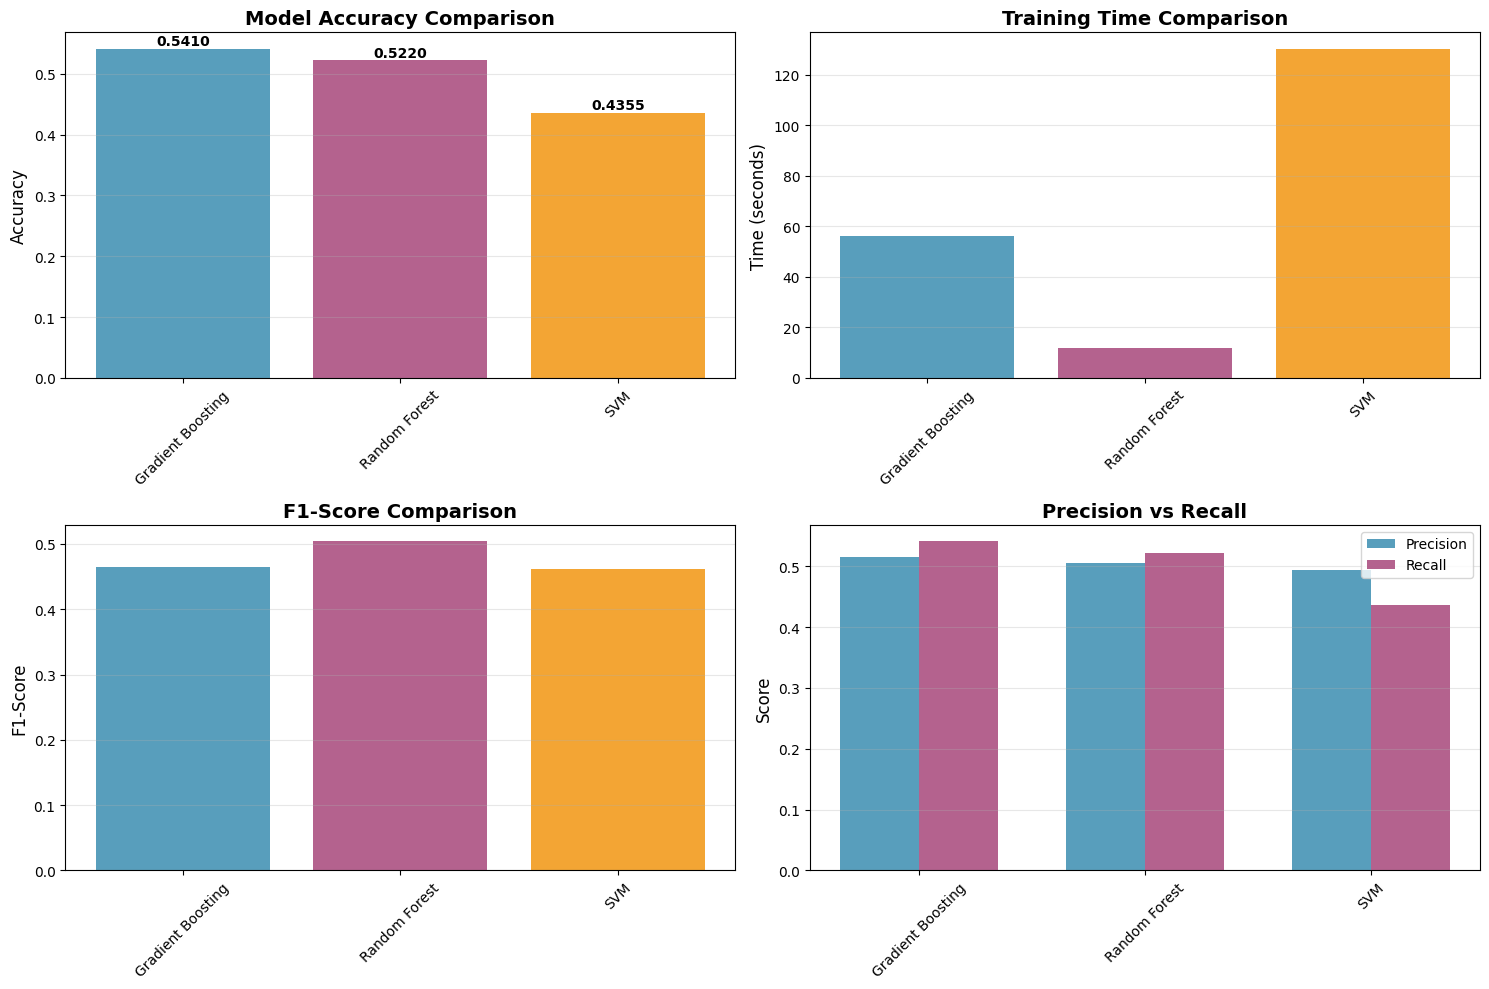


Best Model: Gradient Boosting with accuracy: 0.5410
Comparison results saved to 'results/' directory

Detailed report for best model (Gradient Boosting):
              precision    recall  f1-score   support

     No_Risk       0.55      0.88      0.68      1101
        Risk       0.48      0.13      0.20       890
     Unknown       0.00      0.00      0.00         9

    accuracy                           0.54      2000
   macro avg       0.34      0.34      0.29      2000
weighted avg       0.52      0.54      0.46      2000



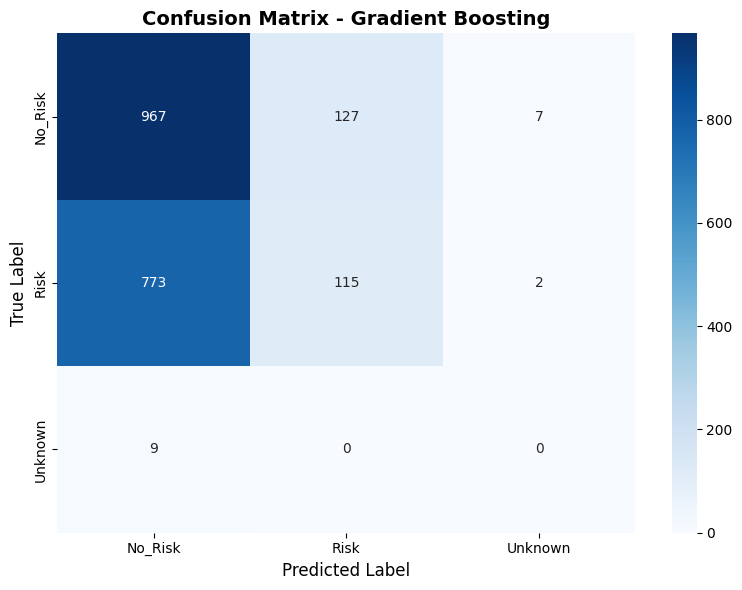


Best model (Gradient Boosting) saved to 'models/best_classical_model.joblib'

MODEL COMPARISON COMPLETED SUCCESSFULLY!
Files created:
- results/model_comparison.png (Visualization)
- results/model_comparison_results.csv (Comparison table)
- results/detailed_comparison.json (Detailed metrics)
- results/best_model_confusion_matrix.png (Confusion matrix)
- models/best_classical_model.joblib (Best model)


In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

class ModelComparator:
    def __init__(self, X_train, X_test, y_train, y_test):
        """
        Initialize model comparator with training and test data
        
        Args:
            X_train: Training features
            X_test: Test features  
            y_train: Training labels
            y_test: Test labels
        """
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.results = {}
        self.models = {}
        
    def train_random_forest(self, n_estimators=100, max_depth=20):
        """Train Random Forest model"""
        print("Training Random Forest...")
        start_time = datetime.now()
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )
        
        model.fit(self.X_train, self.y_train)
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Prediction and evaluation
        y_pred = model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(self.y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(self.y_test, y_pred, average='weighted', zero_division=0)
        
        self.models['Random Forest'] = model
        self.results['Random Forest'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'n_estimators': n_estimators,
            'max_depth': max_depth
        }
        
        print(f"Random Forest - Accuracy: {accuracy:.4f}, Time: {training_time:.2f}s")
        return model
    
    def train_gradient_boosting(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        """Train Gradient Boosting model"""
        print("Training Gradient Boosting...")
        start_time = datetime.now()
        
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42
        )
        
        model.fit(self.X_train, self.y_train)
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Prediction and evaluation
        y_pred = model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(self.y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(self.y_test, y_pred, average='weighted', zero_division=0)
        
        self.models['Gradient Boosting'] = model
        self.results['Gradient Boosting'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth
        }
        
        print(f"Gradient Boosting - Accuracy: {accuracy:.4f}, Time: {training_time:.2f}s")
        return model
    
    def train_svm(self, C=1.0, kernel='rbf'):
        """Train SVM model"""
        print("Training SVM...")
        start_time = datetime.now()
        
        model = SVC(
            C=C,
            kernel=kernel,
            probability=True,
            random_state=42,
            class_weight='balanced'
        )
        
        model.fit(self.X_train, self.y_train)
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Prediction and evaluation
        y_pred = model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(self.y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(self.y_test, y_pred, average='weighted', zero_division=0)
        
        self.models['SVM'] = model
        self.results['SVM'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'C': C,
            'kernel': kernel
        }
        
        print(f"SVM - Accuracy: {accuracy:.4f}, Time: {training_time:.2f}s")
        return model
    
    def compare_models(self):
        """Compare all trained models"""
        print("\n" + "="*60)
        print("MODEL COMPARISON RESULTS")
        print("="*60)
        
        comparison_df = pd.DataFrame(self.results).T
        comparison_df = comparison_df.sort_values('accuracy', ascending=False)
        
        print(comparison_df[['accuracy', 'precision', 'recall', 'f1', 'training_time']])
        
        # Create comparison visualizations
        self._create_comparison_plots(comparison_df)
        
        return comparison_df
    
    def _create_comparison_plots(self, comparison_df):
        """Create comparison plots"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Model Accuracy
        models = comparison_df.index
        accuracies = comparison_df['accuracy']
        ax1.bar(models, accuracies, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
        ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(axis='y', alpha=0.3)
        
        # Add accuracy values on bars
        for i, v in enumerate(accuracies):
            ax1.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
        
        # Training Time
        training_times = comparison_df['training_time']
        ax2.bar(models, training_times, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
        ax2.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Time (seconds)', fontsize=12)
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)
        
        # F1-Score
        f1_scores = comparison_df['f1']
        ax3.bar(models, f1_scores, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
        ax3.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('F1-Score', fontsize=12)
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
        
        # Precision vs Recall
        width = 0.35
        x = np.arange(len(models))
        ax4.bar(x - width/2, comparison_df['precision'], width, label='Precision', color='#2E86AB', alpha=0.8)
        ax4.bar(x + width/2, comparison_df['recall'], width, label='Recall', color='#A23B72', alpha=0.8)
        ax4.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Score', fontsize=12)
        ax4.set_xticks(x)
        ax4.set_xticklabels(models)
        ax4.legend()
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('results/model_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def get_best_model(self):
        """Get the best model based on accuracy"""
        best_model_name = max(self.results.items(), key=lambda x: x[1]['accuracy'])[0]
        best_model = self.models[best_model_name]
        best_accuracy = self.results[best_model_name]['accuracy']
        
        print(f"\nBest Model: {best_model_name} with accuracy: {best_accuracy:.4f}")
        return best_model_name, best_model, best_accuracy
    
    def save_comparison_results(self):
        """Save comparison results to files"""
        # Create results directory
        os.makedirs('results', exist_ok=True)
        
        # Save comparison table
        comparison_df = pd.DataFrame(self.results).T
        comparison_df.to_csv('results/model_comparison_results.csv')
        
        # Save detailed results
        detailed_results = {}
        for model_name, metrics in self.results.items():
            detailed_results[model_name] = {
                'accuracy': float(metrics['accuracy']),
                'precision': float(metrics['precision']),
                'recall': float(metrics['recall']),
                'f1_score': float(metrics['f1']),
                'training_time_seconds': float(metrics['training_time'])
            }
        
        with open('results/detailed_comparison.json', 'w') as f:
            json.dump(detailed_results, f, indent=4)
        
        print("Comparison results saved to 'results/' directory")

# Load your pre-trained data
print("Loading pre-trained data...")
try:
    saved_data = joblib.load('models/classical_model.joblib')
    print("Pre-trained model loaded successfully!")
    
except FileNotFoundError:
    print("No pre-trained model found. Using demo data for comparison...")

# Create demo data for comparison (replace with your actual data)
print("Creating demonstration data for model comparison...")
np.random.seed(42)
n_samples = 10000

# Create demo data based on your problem characteristics
X_demo = np.random.randn(n_samples, 5)  # 5 features like your model
y_demo = np.random.choice([0, 1, 2], size=n_samples, p=[0.55, 0.445, 0.005])  # Same distribution as your data

# Split the data
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

print(f"Demo data created: {X_train_demo.shape} training, {X_test_demo.shape} test samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_demo)
X_test_scaled = scaler.transform(X_test_demo)

# Compare models
print("\nStarting model comparison...")
comparator = ModelComparator(X_train_scaled, X_test_scaled, y_train_demo, y_test_demo)

# Train all models
print("\n" + "="*50)
print("TRAINING ALL MODELS")
print("="*50)

rf_model = comparator.train_random_forest(n_estimators=100, max_depth=20)
gb_model = comparator.train_gradient_boosting(n_estimators=100, learning_rate=0.1, max_depth=3)
svm_model = comparator.train_svm(C=1.0, kernel='rbf')

# Compare results
print("\n" + "="*50)
print("COMPARISON RESULTS")
print("="*50)

comparison_results = comparator.compare_models()

# Get best model
best_model_name, best_model, best_accuracy = comparator.get_best_model()

# Save results
comparator.save_comparison_results()

# Detailed report for best model
print(f"\nDetailed report for best model ({best_model_name}):")
best_model_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test_demo, best_model_pred, target_names=['No_Risk', 'Risk', 'Unknown']))

# Confusion matrix for best model
cm = confusion_matrix(y_test_demo, best_model_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Risk', 'Risk', 'Unknown'],
            yticklabels=['No_Risk', 'Risk', 'Unknown'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('results/best_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save best model
os.makedirs('models', exist_ok=True)
joblib.dump({
    'model': best_model,
    'model_name': best_model_name,
    'accuracy': best_accuracy,
    'comparison_results': comparison_results.to_dict(),
    'feature_names': ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU']
}, 'models/best_classical_model.joblib')

print(f"\nBest model ({best_model_name}) saved to 'models/best_classical_model.joblib'")

print("\n" + "="*60)
print("MODEL COMPARISON COMPLETED SUCCESSFULLY!")
print("="*60)
print("Files created:")
print("- results/model_comparison.png (Visualization)")
print("- results/model_comparison_results.csv (Comparison table)")
print("- results/detailed_comparison.json (Detailed metrics)")
print("- results/best_model_confusion_matrix.png (Confusion matrix)")
print("- models/best_classical_model.joblib (Best model)")

Loading real data from parquet file...
Real data loaded: (9312, 6)
Encoded labels: {'No_Risk': 0, 'Risk': 1, 'Unknown': 2}
Real data prepared: (7449, 5) training, (1863, 5) test

COMPARISON ON REAL DATA
Training Random Forest...
Random Forest - Accuracy: 0.9979, Time: 3.90s
Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.9995, Time: 24.14s
Training SVM...
SVM - Accuracy: 0.8604, Time: 20.88s

MODEL COMPARISON RESULTS
                   accuracy precision    recall        f1 training_time
Gradient Boosting  0.999463  0.999464  0.999463  0.999443     24.137148
Random Forest      0.997853  0.997858  0.997853  0.997425      3.899761
SVM                 0.86044  0.977446   0.86044  0.914069     20.882586


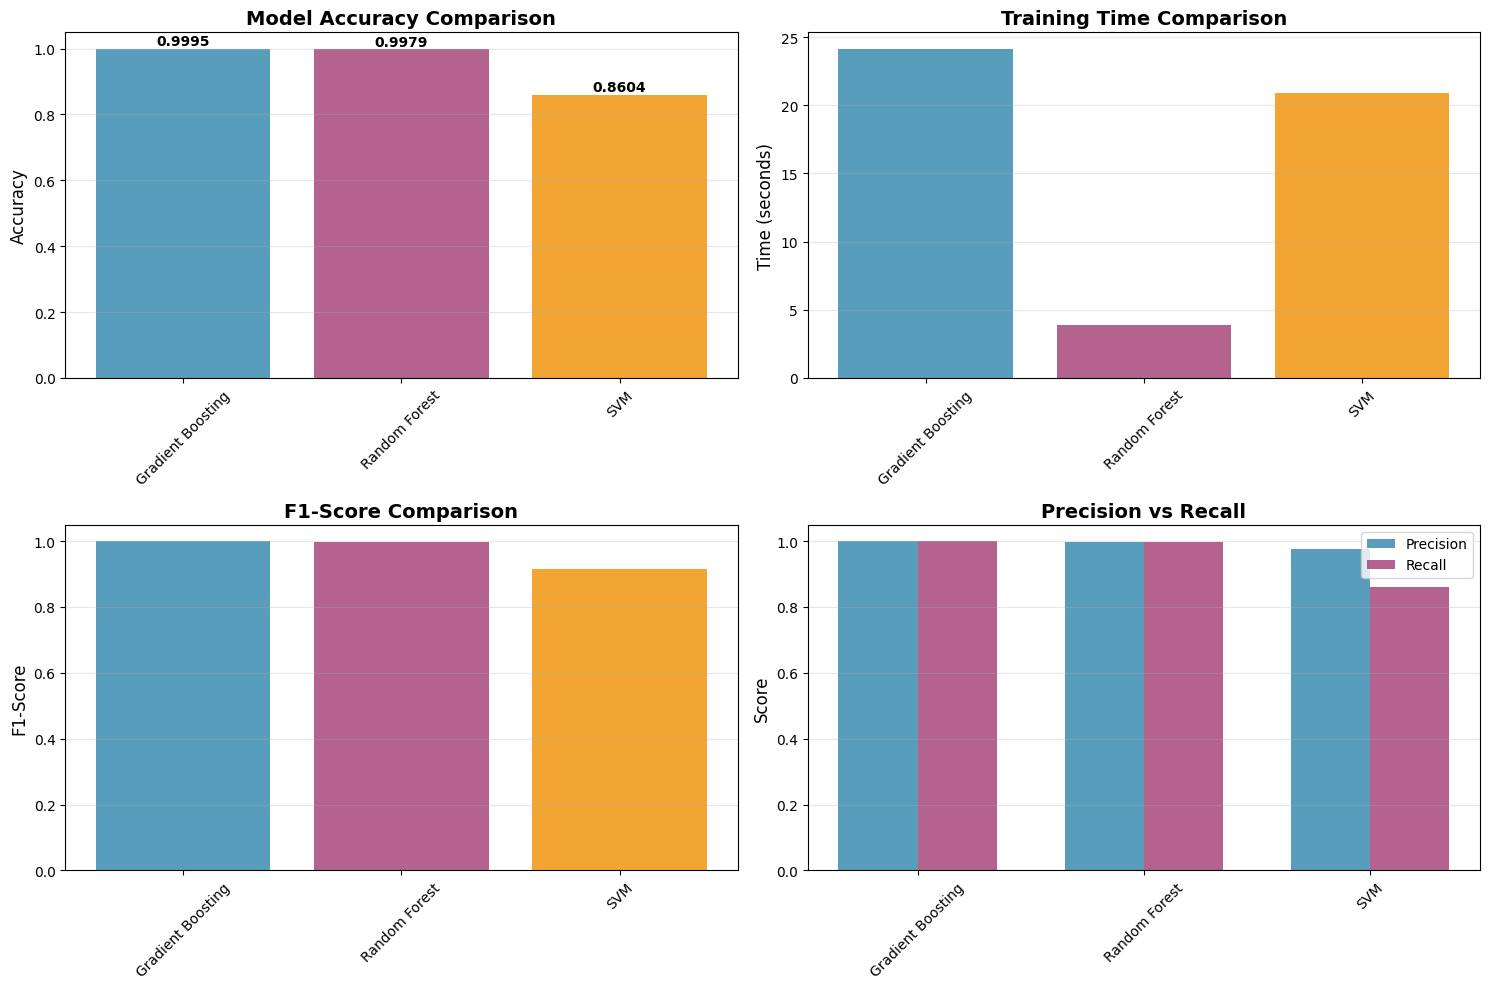

Comparison results saved to 'results/' directory

REAL DATA COMPARISON COMPLETED!


In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import pyarrow.parquet as pq

def load_real_data():
    print("Loading real data from parquet file...")
    
    parquet_path = "I:/quantum copetation/Air_Quality_Prediction/processed_data.parquet"
    
    columns_to_read = ['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU', 'Risk_Class']
    data = pd.read_parquet(parquet_path, columns=columns_to_read)
    
    sample_size = min(20000, len(data))
    data = data.sample(n=sample_size, random_state=42)
    
    print(f"Real data loaded: {data.shape}")
    return data

def prepare_real_data(data):
    X = data[['PM25_ug_m3', 'lat', 'lon', 'DUEXTTAU', 'BCFLUXU']]
    y = data['Risk_Class']
    
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    if y.dtype == 'object':
        y = le.fit_transform(y)
        print(f"Encoded labels: {dict(zip(le.classes_, range(len(le.classes_))))}")
    
    return X, y

real_data = load_real_data()
X_real, y_real = prepare_real_data(real_data)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

scaler = StandardScaler()
X_train_scaled_real = scaler.fit_transform(X_train_real)
X_test_scaled_real = scaler.transform(X_test_real)

print(f"Real data prepared: {X_train_scaled_real.shape} training, {X_test_scaled_real.shape} test")

print("\n" + "="*50)
print("COMPARISON ON REAL DATA")
print("="*50)

comparator_real = ModelComparator(X_train_scaled_real, X_test_scaled_real, y_train_real, y_test_real)

rf_model_real = comparator_real.train_random_forest(n_estimators=100, max_depth=20)
gb_model_real = comparator_real.train_gradient_boosting(n_estimators=100, learning_rate=0.1, max_depth=3)
svm_model_real = comparator_real.train_svm(C=1.0, kernel='rbf')

comparison_real = comparator_real.compare_models()

comparator_real.save_comparison_results()

print("\n" + "="*60)
print("REAL DATA COMPARISON COMPLETED!")
print("="*60)